# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [5]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1204s 7us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

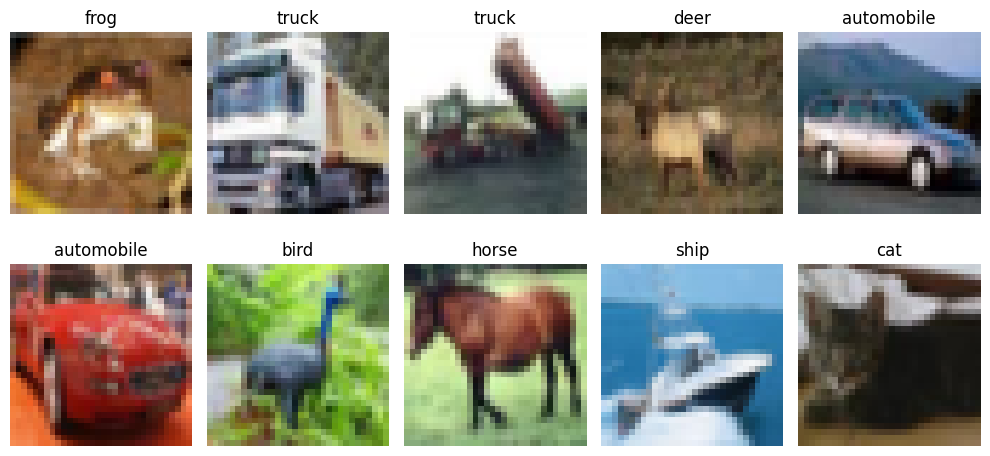

In [6]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [7]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

# Task 4: Add EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [9]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.2702 - loss: 1.9923 - val_accuracy: 0.2910 - val_loss: 1.9023
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.3189 - loss: 1.8660 - val_accuracy: 0.3566 - val_loss: 1.8005
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.3378 - loss: 1.8120 - val_accuracy: 0.3882 - val_loss: 1.7240
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.3591 - loss: 1.7642 - val_accuracy: 0.3634 - val_loss: 1.7455
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3728 - loss: 1.7305 - val_accuracy: 0.3962 - val_loss: 1.7136
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.3782 - loss: 1.7123 - val_accuracy: 0.4102 - val_loss: 1.6742
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3904 - loss: 1.6920 - val_accuracy: 0.4152 - val_loss: 1.6271
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.3922 - loss: 1.6743 - 

In [10]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)
print("ANN Test Loss:", ann_test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4205 - loss: 1.6214
ANN Test Accuracy: 0.4205000102519989
ANN Test Loss: 1.6213953495025635


# After The Updatation of the ANN Code

In [11]:
Updated_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

Updated_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Updated_ann_history = Updated_ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.2557 - loss: 2.0251 - val_accuracy: 0.3378 - val_loss: 1.8625
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.3153 - loss: 1.8718 - val_accuracy: 0.3386 - val_loss: 1.8190
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.3359 - loss: 1.8264 - val_accuracy: 0.3746 - val_loss: 1.7632
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 62ms/step - accuracy: 0.3552 - loss: 1.7803 - val_accuracy: 0.3800 - val_loss: 1.7316
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 63ms/step - accuracy: 0.3643 - loss: 1.7584 - val_accuracy: 0.3912 - val_loss: 1.7306
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.3694 - loss: 1.7415 - val_accuracy: 0.4088 - val_loss: 1.6563
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.3811 - loss: 1.7193 - val_accuracy: 0.4154 - val_loss: 1.6727
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 62ms/step - accuracy: 0.3831 - loss: 1.7057 - 

In [12]:
updated_ann_test_loss, updated_ann_test_acc = Updated_ann_model.evaluate(x_test_flat, y_test)
print("Updated ANN Test Accuracy:", updated_ann_test_acc)
print("Updated ANN Test Loss:", updated_ann_test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4499 - loss: 1.5768
Updated ANN Test Accuracy: 0.4499000012874603
Updated ANN Test Loss: 1.5768462419509888


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [13]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 114ms/step - accuracy: 0.4587 - loss: 1.5115 - val_accuracy: 0.4540 - val_loss: 1.5896
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 114ms/step - accuracy: 0.6046 - loss: 1.1337 - val_accuracy: 0.5798 - val_loss: 1.1999
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 115ms/step - accuracy: 0.6638 - loss: 0.9598 - val_accuracy: 0.6542 - val_loss: 0.9727
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.7082 - loss: 0.8453 - val_accuracy: 0.6470 - val_loss: 1.0143
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 116ms/step - accuracy: 0.7377 - loss: 0.7505 - val_accuracy: 0.6564 - val_loss: 0.9942
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 113ms/step - accuracy: 0.7636 - loss: 0.6733 - val_accuracy: 0.6504 - val_loss: 1.0960
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.7887 - loss: 0.6030 - val_accuracy: 0.6800 - val_loss: 1.0346
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.8070 - loss: 0

In [14]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)
print("CNN Test Loss:", cnn_test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7288 - loss: 0.9201
CNN Test Accuracy: 0.7287999987602234
CNN Test Loss: 0.9200812578201294


# After the Updatation in the CNN code

In [15]:
Updated_cnn_model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

Updated_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Updated_cnn_history = Updated_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 215s 301ms/step - accuracy: 0.4800 - loss: 1.4861 - val_accuracy: 0.3964 - val_loss: 2.2119
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 257s 294ms/step - accuracy: 0.6227 - loss: 1.0760 - val_accuracy: 0.6240 - val_loss: 1.0562
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 264s 298ms/step - accuracy: 0.6889 - loss: 0.8967 - val_accuracy: 0.6240 - val_loss: 1.0761
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 208s 295ms/step - accuracy: 0.7315 - loss: 0.7720 - val_accuracy: 0.5784 - val_loss: 1.5107
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 215s 306ms/step - accuracy: 0.7683 - loss: 0.6680 - val_accuracy: 0.5874 - val_loss: 1.5250


In [16]:
updated_cnn_test_loss, updated_cnn_test_acc = Updated_cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", updated_cnn_test_acc)
print("CNN Test Loss:", updated_cnn_test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.6013 - loss: 1.1156
CNN Test Accuracy: 0.6013000011444092
CNN Test Loss: 1.1155595779418945


## 📈 Compare Learning Curves

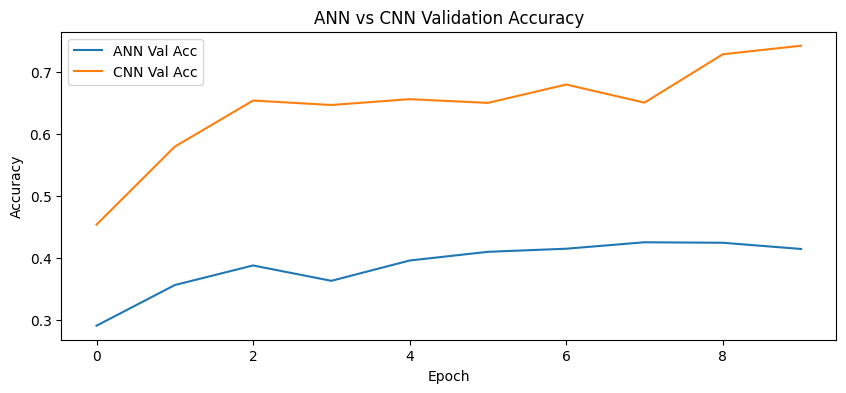

In [17]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

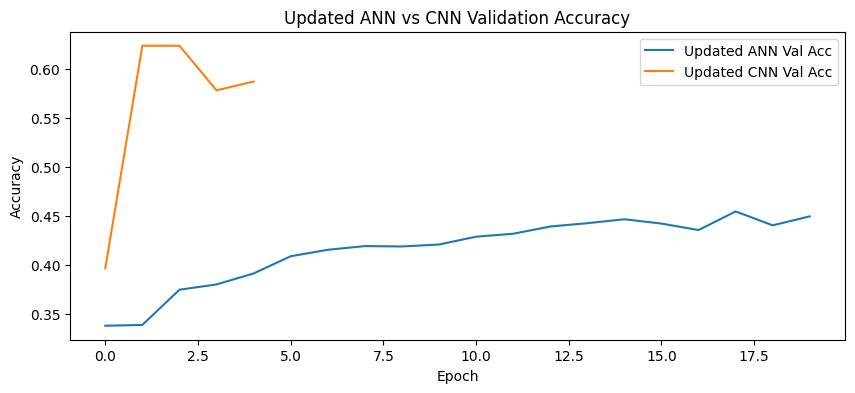

In [18]:
plt.figure(figsize=(10,4))
plt.plot(Updated_ann_history.history['val_accuracy'], label='Updated ANN Val Acc')
plt.plot(Updated_cnn_history.history['val_accuracy'], label='Updated CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Updated ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [19]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=20, validation_split=0.1)
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)
print("Augmented CNN Test Loss:", aug_test_loss)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 47ms/step - accuracy: 0.3757 - loss: 1.7032 - val_accuracy: 0.5046 - val_loss: 1.3518
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 47ms/step - accuracy: 0.4750 - loss: 1.4563 - val_accuracy: 0.5328 - val_loss: 1.2990
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 49ms/step - accuracy: 0.5157 - loss: 1.3614 - val_accuracy: 0.5948 - val_loss: 1.1300
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 48ms/step - accuracy: 0.5350 - loss: 1.3037 - val_accuracy: 0.5958 - val_loss: 1.1494
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 47ms/step - accuracy: 0.5525 - loss: 1.2630 - val_accuracy: 0.6204 - val_loss: 1.0664
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.5654 - loss: 1.2260 - val_accuracy: 0.6302 - val_loss: 1.0472
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.5752 - loss: 1.1959 - val_accuracy: 0.6452 - val_loss: 1.0247
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 46ms/step - accuracy: 0.5874 -

# 📊 Final Comparison Table

In [20]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4205
1,CNN,0.7288


In [22]:
comparison = pd.DataFrame({
    "Model": ["Updated_ANN", "Updated_ CNN", "Augmented CC"],
    "Test Accuracy": [updated_ann_test_acc, updated_cnn_test_acc, aug_test_acc]
})
comparison

,Model,Test Accuracy
0,Updated_ANN,0.4499
1,Updated_ CNN,0.6013
2,Augmented CC,0.6787


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**